# Numerical Solution of the Hydrogen Radial Equation

## Abstract
Understanding atomic structure begins with solving the hydrogen atom, which lays the foundation for chemistry and understaning the periodic table. In this project, I numerically solve the radial Schroedinger equation for the hydrogen atom using the direct matrix method for eigenvalue problems. By discretizing the radial part of the Schroedinger equation and converting it into a matrix eigenvalue problem, I compute the eigenvalues and eigenvectors using NumPy’s built-in solver. The resulting eigenenergies closely match the known analytical energy levels, and the computed radial wavefunctions overlap precisely with the exact solutions. I then use these wavefunctions to calculate and visualize the electron probability densities for orbitals with angular momentum quantum numbers l=0, 1, and 2. This approach demonstrates how numerical methods can accurately capture fundamental quantum behavior and provides a stepping stone toward solving more complex, multi-electron systems where analytical solutions are not available.

## Introduction
The hydrogen atom is a seemingly simple quantum mechanics problem with an electron orbiting a stationary proton. The potential for this setup is the Coloumb potential between the proton and electron, each with charge $e$.
\begin{equation}
    V(r)=\frac{-e^2}{4\pi\epsilon_0r}
\end{equation}
Because this potential is spherically symmetric, we can convert to spherical coordinates to solve the problem more naturally. To begin solving this problem, we'll look for separable solutions of the form $\psi(r,\theta,\phi) = R(r)Y(\theta,\phi)$, where $R(r)$ is the radial part of the solution and $Y(\theta,\phi)$ is the angular part. Inputting this solution form into the Schroedinger Equation
\begin{equation}
    - \frac{\hbar^2}{2m}\nabla^2 \psi + V \psi = E\psi
\end{equation}
with spherical coordinate Laplacian
\begin{equation}
    \nabla^2 = \frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial}{\partial r} \right) + \frac{1}{r^2 \sin(\theta)} \frac{\partial}{\partial \theta} \left( \sin \theta \frac{\partial}{\partial \theta} \right) + \frac{1}{r^2 \sin^2(\theta)} \left( \frac{\partial^2}{\partial \phi^2} \right)
\end{equation}
we find the equation separates into
\begin{equation}
    \Biggl\{ \frac{1}{R}\frac{d}{dr}\left(r^2 \frac{dR}{dr}\right) - \frac{2mr^2}{\hbar^2} [V(r) - E] \Biggl\} + \frac{1}{Y} \Biggl\{ \frac{1}{\sin \theta} \frac{\partial}{\partial\theta} \left( \sin \theta \frac{\partial Y}{\partial \theta} \right) + \frac{1}{\sin^2 \theta} \frac{\partial^2 Y}{\partial \theta^2} \Biggl \} = 0
\end{equation}
where the first part is the radial equation and the second part is the angular equation. The angular equation does not involve the potential and thus its solutions are not specific to any spherically symmetric potential. The solutions to this equation are the spherical harmonics. 

To solve the radial equation, first set it equal to the constant of separation $l(l+1)$, which comes from angular momentum.
\begin{equation}
    \frac{d}{dr}\left(r^2 \frac{dR}{dr}\right) - \frac{2mr^2}{\hbar^2} [V(r) - E]R = l(l+1)R
\end{equation}
This equation is difficult to solve though. We can make this equation easier to solve by introducing the clever substition 
\begin{equation}
    u(r)=rR(r) \Rightarrow R(r)=\frac{u(r)}{r}
\end{equation}
which allows us to rewrite the radial equation as 
\begin{equation}
    r\frac{d^2u}{dr^2}-\frac{2mr}{\hbar^2}[V(r) - E]u = \frac{l(l+1)}{r}u.
\end{equation}
With some manipulation we can rewrite this equation as 
\begin{equation}
    \frac{-\hbar^2}{2m}\frac{d^2u}{dr^2}+\left[ V(r) + \frac{\hbar^2}{2m}\frac{l(l+1)}{r^2} \right] u = Eu
\end{equation}
which is the same form of the Schroedinger equation but with an effective potential that is made of the potential for the problem $V(r)$ and also a centrifugal term that arises from the angular momentum of the orbiting electron. Inputting the Coulomb potential we now have the radial equation of the hydrogen atom that we seek to solve.
\begin{equation}
    \frac{-\hbar^2}{2m}\frac{d^2u}{dr^2}+\left[ \frac{-e^2}{4\pi\epsilon_0r} + \frac{\hbar^2}{2m}\frac{l(l+1)}{r^2} \right] u = Eu
\end{equation}

## Solution of the Radial Equation
To solve this problem numerically, I'll use the direct matrix method for eigenvalue problems. Firstly, I'll use the central difference method for the second derivative
\begin{equation}
    \frac{-\hbar^2}{2m}\left[ \frac{u(r_{i+1}) + u(r_{i-1}) - 2u(r_i)}{\Delta x^2} \right] - \frac{e^2}{4\pi\epsilon_0r_i} u(r_i) + \frac{\hbar^2}{2m}\frac{l(l+1)}{r_i^2} u(r_i) = Eu(r_i)
\end{equation}
I'll introduce the constant $k=\frac{\hbar^2}{2m}\frac{1}{\Delta x^2}$ and group the potential terms into $V_i = - \frac{e^2}{4\pi\epsilon_0r_i} + \frac{\hbar^2}{2m}\frac{l(l+1)}{r_i^2}$ so that I can rewrite the radial equation as 
\begin{equation}
    -ku_{i+1} -ku_{i-1} + (2k+V_i)u_i = Eu_i
\end{equation}
which can be turned into a matrix eigenvalue equation. The eigenvectors of this matrix problem will be the $\textbf{u}$ vectors which I will normalize using Simpson's method and then the actual radial equation is found by diving by $r$.

## Implementation
To implement this method to solve the radial equation, first I'll import the dependecies and create functions for the effective potential and Simpson's method. I check the value of the Bohr radius to make sure all my constants are correct.

In [1]:
from scipy import constants as const
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# constants
e = const.e
hbar = const.hbar
eps_0 = const.epsilon_0
m_e = const.m_e
pi = const.pi
a = 4 * pi * eps_0 * hbar**2 / m_e / e**2
print("The Bohr raduis is ",a," meters.")

# define the potential
def V(r, l):
    alpha = e**2 / (4 * pi * eps_0)
    beta = (hbar**2 / 2 / m_e) * l * (l+1)
    return -alpha / r + beta / r**2

# Define function for Simpson's rule
def Simpson(psi, a, b, n):
    if n % 2 == 0:
        print('Error: n must be an odd number!')
    else:
        h = (b-a)/(n-1)
        x = np.linspace(a,b,n)

        # Create array of c_i
        c = np.ones(n)
        for i in range(len(c)):
            if i % 2 == 0:
                c[i] = 2
            else:
                c[i] = 4
        c[0], c[-1] = 1, 1

        contribution = (h/3)*c*psi
        return np.sum(contribution)

The Bohr raduis is  5.291772105443463e-11  meters.


Here I code the analytical solutions of the radial equation to check my numerical solution against.

In [3]:
# create a function for plotting the actul results
def Actual_Radial_Func(r,n,l):
    expo = np.exp(-r/(n*a))
    if n == 1:
        return 2 * a**(-1.5) * expo
    if n == 2:
        if l == 0:
            poly = 1 - r / (2*a)
            return (1/np.sqrt(2)) * a**(-1.5) * poly * expo
    if n==3:
        if l == 1: 
            const = 8 * a**(-1.5) / (27*np.sqrt(6))
            poly = (1 - r / (6*a)) * (r/a)
            return const * poly * expo
        if l==2:
            const = 4 * (a**-1.5) / (81 * np.sqrt(30))
            poly = (r/a)**2
            return const * poly * expo

Now I'll implement the matrix method. Firstly, I discretize the r-grid. I choose $r$ to range from 0 to $100a$ since this is far enough for the analytical solutions to get close to zero. Then I define a function that will take a value of $l$  and return the first three eigenenergies and eigenvectors for that value of $l$. This function first builds the Hamiltonian matrix. This matrix is of size $(n-2)\times(n-2)$ because I'm leaving off the extreme $r$ values, $r=0$ and $r=100a$. The radial equation should be 0 at these $r$ values and I'll add that in later. I choose $n$ to be 1001 so that the eigenvalue solver doesn't take too long to solve but this still gives me a rather high accuracy, which will be seen later. Then I define a function that takes the $\textbf{u}$ vector, adds the boundary conditions $u(0)=u(\infty)=0$, and normalizes $\textbf{u}$. I use the Simpson's method function that I defined earlier to do the integration of $\textbf{u}$. The function then returns $R(r)$ by dividing $\textbf{u}$ by $r$.

In [4]:
# quantum numbers
l = 0

# discretize the r-grid
r_i = 0
r_f = 100*a
n = 1001
dx = (r_f-r_i) / (n-1)
k = hbar**2 / (2 * m_e * dx**2)

r = np.linspace(r_i,r_f,n)
r_plot = r[1:-1] # r array with first and last elements removed

def Solve(l=0):
    '''
    function that will solve the Hamiltonian eigenvalue problem
    and return the first three eigenvectors and values for a given
    l value
    '''
    # build the hamiltonian matrix
    H = np.zeros((n-2,n-2))
    
    H[0][0] = 2*k + V(r[1],l)
    H[0][1] = -k
    
    H[-1][-2]= -k
    H[-1][-1]= 2*k + V(r[n-2],l)
    
    for ii in range(1,n-3):
        H[ii][ii] = 2*k + V(r[ii+1],l)
        H[ii][ii+1] = -k
        H[ii][ii-1] = -k

    # solve the Hamiltonian eigenenergies and vectors
    vals, vecs = np.linalg.eigh(H)
    energies = vals[0:3]/e # return the first three energies in eV

    # create an array that will store the first three eigenvectors
    wavefuncs = np.zeros((n-2,3))
    wavefuncs = vecs[:,0:3]
    
    # return the first three energies and vectors
    return energies, wavefuncs

# define a function that will create and normalize the actual radial wavefunction from u
def Normalization(u):
    ret_psi = np.zeros((n,3))
    for i in range(3):
        # create the radial function from u and add boundary conditions
        ret_psi[1:-1,i] = u[:,i] 
    
        # normalize the wavefunction
        I = Simpson(ret_psi[:,i]**2,r_i,r_f,n)
        c = 1 / np.sqrt(I)
        ret_psi[:,i] = c * ret_psi[:,i]
    
        # return the radial function
        ret_psi[1:-1,i] = ret_psi[1:-1,i] / r_plot
    return ret_psi

Now I'll begin solving the radial equation. Firstly, I'll plot the effective potential. Since I'm solving the $l=0$ case first there is no angular momentum and the effective potential is just the Coulomb potential.

Text(0, 0.5, '$V_{eff}(r)$')

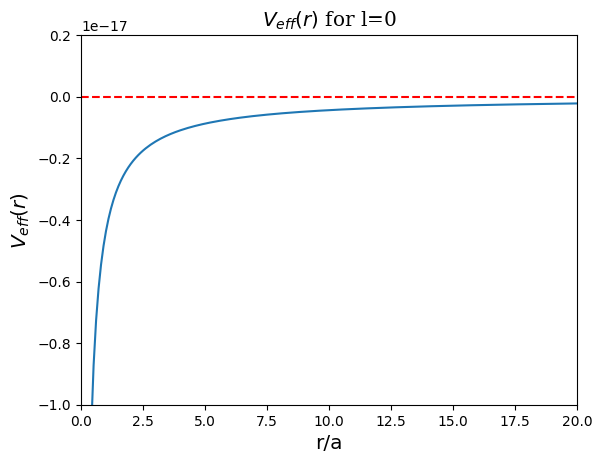

In [5]:
# Plot of the effective potential for l=0
plt.plot(r_plot/a,V(r_plot,0))
plt.axhline(y=0,ls='--',c='r')
plt.xlim(0,20)
plt.ylim(-1e-17,0.2e-17)
plt.title('$V_{eff}(r)$ for l=0',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel('$V_{eff}(r)$',fontsize='x-large')
# plt.savefig('Veff l0.jpg',bbox_inches='tight')

Text(0, 0.5, '$R_{n0}(r)$')

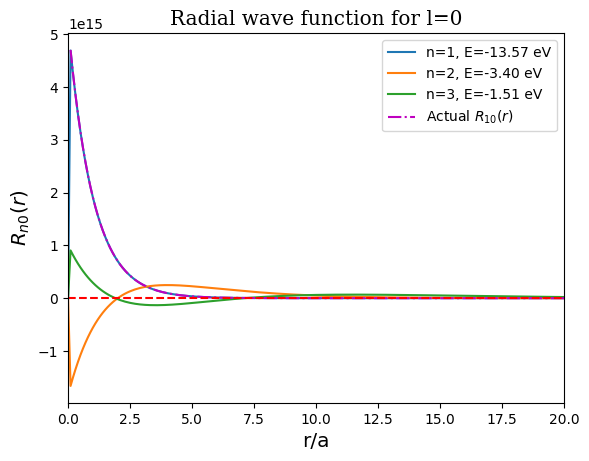

In [6]:
# Solve for the eigenenergies and vectors for l = 0
energies, psis_0 = Solve()
norm_radial_0 = Normalization(psis_0)
for i in range(3):
    plt.plot(r/a,-norm_radial_0[:,i],label=f'n={i+1}, E={energies[i]:.2f} eV')
plt.plot(r_plot/a,Actual_Radial_Func(r_plot,1,0),label='Actual $R_{10}(r)$',ls='-.',c='m')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,20)
plt.title('Radial wave function for l=0',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$R_{n0}(r)$',fontsize='x-large')
# plt.savefig('Radial Wave Func l0',bbox_inches='tight')

Here I plotted the first three solutions, corresponding to $n=1,2,3$, their corresponding energies, and the analytical $R_{10}(r)$ solution. Firstly, the eigenenergies are quite close to their actual values. It is known that the lowest energy should be -13.6 eV and the lowest energy given by the method is only a few percent off from this. If I were to include the extreme $r$ values the energies might be closer. Next, the higher energies are indeed the lowest energy divided by $n^2$. Lastly, the analytical $R_{10}(r)$ solution lies directly on top of the numerical solution showing that the method is quite accurate.

Next, I'll solve the $l=1$ and $l=2$ cases.

Text(0, 0.5, '$V_{eff}(r)$')

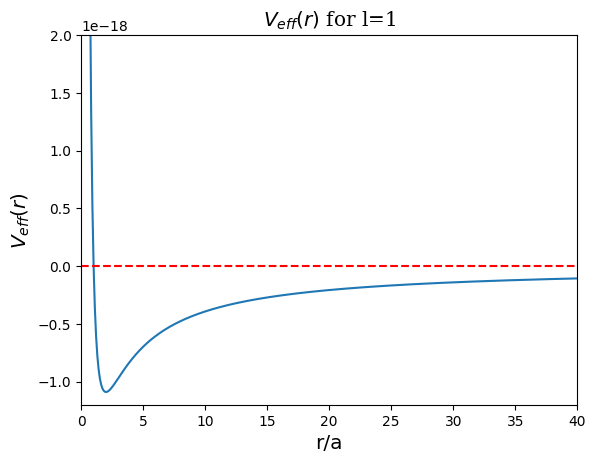

In [7]:
# Plot of the effective potential for l=1
plt.plot(r_plot/a,V(r_plot,1))
plt.axhline(y=0,ls='--',c='r')
plt.xlim(0,40)
plt.ylim(-0.12e-17,0.2e-17)
plt.title('$V_{eff}(r)$ for l=1',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel('$V_{eff}(r)$',fontsize='x-large')
# plt.savefig('Veff l1',bbox_inches='tight')

In [8]:
#  l = 1
energies_1, psis_1 = Solve(l=1)
norm_radial_1 = Normalization(psis_1)

Text(0, 0.5, '$R_{n1}(r)$')

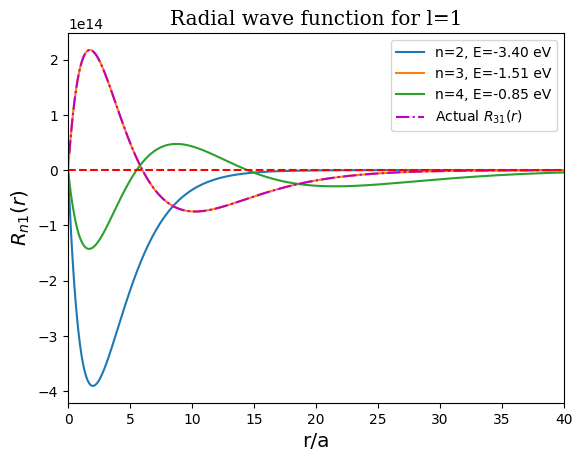

In [9]:
for i in range(3):
    plt.plot(r/a,norm_radial_1[:,i],label=f'n={i+2}, E={energies_1[i]:.2f} eV')
plt.plot(r_plot/a,Actual_Radial_Func(r_plot,3,1),label='Actual $R_{31}(r)$',ls='-.',c='m')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,40)
plt.title('Radial wave function for l=1',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$R_{n1}(r)$',fontsize='x-large')
# plt.savefig('Radial wave func l1',bbox_inches='tight')

Once again, the energies come out to be correct. Since $l=1$, the lowest $n$ value is 2 and the lowest energy is the correct $n=2$ energy. Again, the analytical solution is right on top of the numerical solution showing the accuracy of the method.

Text(0, 0.5, '$V_{eff}(r)$')

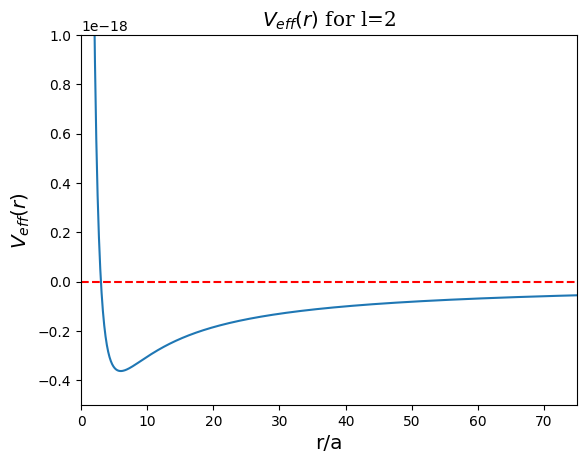

In [10]:
# Plot of the effective potential for l=2
plt.plot(r_plot/a,V(r_plot,2))
plt.axhline(y=0,ls='--',c='r')
plt.xlim(0,75)
plt.ylim(-0.05e-17,0.1e-17)
plt.title('$V_{eff}(r)$ for l=2',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel('$V_{eff}(r)$',fontsize='x-large')
# plt.savefig('Veff l2',bbox_inches='tight')

In [11]:
# l = 2
energies_2, psis_2 = Solve(l=2)
norm_radial_2 = Normalization(psis_2)

Text(0, 0.5, '$R_{n2}(r)$')

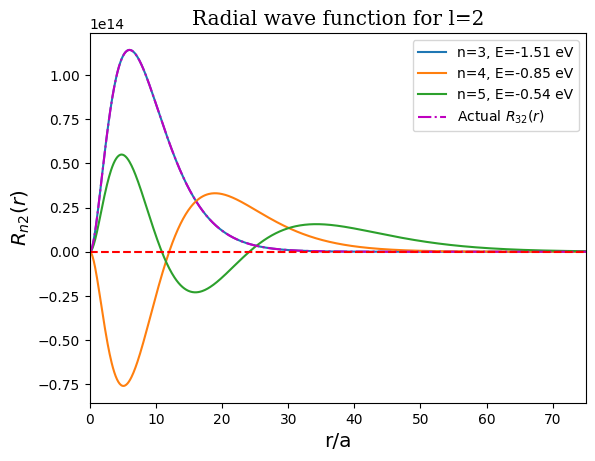

In [12]:
for i in range(3):
    plt.plot(r/a,-norm_radial_2[:,i],label=f'n={i+3}, E={energies_2[i]:.2f} eV')
plt.plot(r_plot/a,Actual_Radial_Func(r_plot,3,2),label='Actual $R_{32}(r)$',ls='-.',c='m')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,75)
plt.title('Radial wave function for l=2',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$R_{n2}(r)$',fontsize='x-large')
# plt.savefig('Radial wave func l2',bbox_inches='tight')

Again, for the $l=2$ case the energies come out correct and the analytical solution is directly on top of the numerical one.

### Plotting the square of the wave function
Now I'll plot the square of the radial equation to see the probability density.

Text(0, 0.5, '$|R_{n0}(r)|^2$')

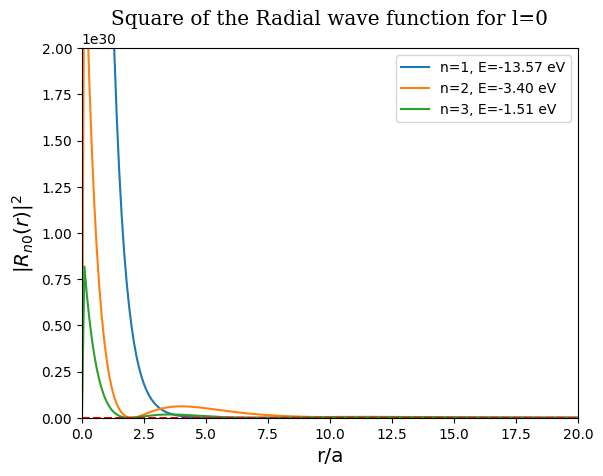

In [13]:
# l = 0
for i in range(3):
    plt.plot(r/a,norm_radial_0[:,i]**2,label=f'n={i+1}, E={energies[i]:.2f} eV')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,20)
plt.ylim(0,0.2e31)
plt.title('Square of the Radial wave function for l=0',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$|R_{n0}(r)|^2$',fontsize='x-large')
# plt.savefig('Square Radial func l0',bbox_inches='tight')

Text(0, 0.5, '$|R_{n1}(r)|^2$')

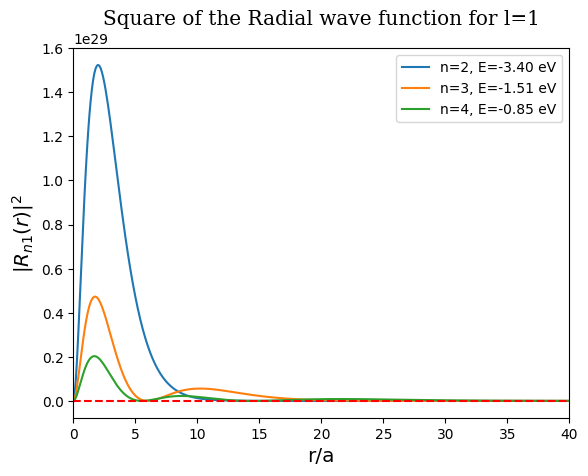

In [14]:
# l = 1
for i in range(3):
    plt.plot(r/a,norm_radial_1[:,i]**2,label=f'n={i+2}, E={energies_1[i]:.2f} eV')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,40)
plt.title('Square of the Radial wave function for l=1',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$|R_{n1}(r)|^2$',fontsize='x-large')
# plt.savefig('square radial func l1',bbox_inches='tight')

Text(0, 0.5, '$|R_{n2}(r)|^2$')

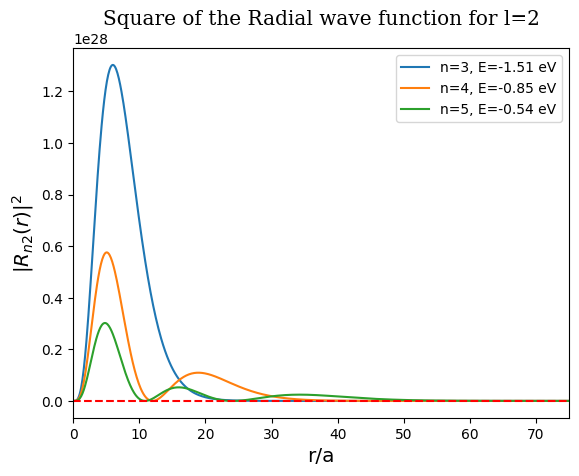

In [15]:
# l = 2
for i in range(3):
    plt.plot(r/a,norm_radial_2[:,i]**2,label=f'n={i+3}, E={energies_2[i]:.2f} eV')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,75)
plt.title('Square of the Radial wave function for l=2',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$|R_{n2}(r)|^2$',fontsize='x-large')
# plt.savefig('Square radial func l2',bbox_inches='tight')

As can be seen for all cases, the probability density is peaked around the minimum in the effective potential, which is to be expected since it is most likely to find the electron at a point of equilibrium. However, because of the uncertainty principle, the wave function spreads outward and the corresponding probability density is also spread outward.

## Angular part
Now I want to plot the electron orbitals using the radial solutions I calculated. The electron orbitals are the square of the wavefunction, thus to plot the orbitals I'll take my radial solution and multiply by the corresponding Spherical Harmonic. 
\begin{equation}
    \psi_{nlm} = R_{nl}(r) Y_l^m(\theta,\phi)
\end{equation}
To plot the orbital, I create a function that takes in the radial solution, the quantum numbers $nlm$, and a number $j$ such that $r$ is plotted from 0 to $ja$. The function creates a mesh of r values such that $r \in [0,ja]$ and phi values such that $\phi \in [0,2\pi]$. The angular function is then plotted on the mesh. I make an array where each row of the array is just the radial solution so that this can be multiplied by the angular mesh to create an arary to be plotted. Then to plot the orbital I use a contour plot on polar coordinates to plot $RY$. I plot orbitals corresponding to each radial solution I calculated, namely the 1s, 2s, 3s, 2p, 3p, 4p, 3d, 4d, and 5d orbitals. All of the plots are in the $X-Y$ plane where $\theta = 90^o$.

In [16]:
# make the function for the angular functions
def Angular_Functions(phi,l,m):
    if l == 0:
        const = np.sqrt(1/(4*pi))
        return const
    if l == 1:
        if m == 0:
            const = np.sqrt(3/(4*pi))
            return const
        else:
            const = np.sqrt(3/(8*pi))
            if m == 1:
                return -const * np.cos(phi)
            if m == -1:
                return const * np.cos(phi)
    if l == 2:
        if m == 0:
            return 2 * np.sqrt(5/(16*pi))
        elif abs(m) == 1:
            const = np.sqrt(15/(8*pi))
        elif abs(m) == 2:
            return np.sqrt(15/(32*pi)) * np.cos(2*phi)

In [17]:
def Plot_Orbital(R,n_quant,l,m,j):
    '''
    Function that takes in the radial solution,
    quantum numbers nlm, and j s.t. r goes from 0
    to ja and plots the corresponding orbital on a 
    polar contour plot
    '''
    # create rmesh and phi mesh
    k = 100 / j
    n_f = int(np.ceil(n/k))
    rlist = np.linspace(0,j*a,n_f)
    philist = np.radians(np.arange(0,361,1))
    rmesh,phimesh = np.meshgrid(rlist,philist)

    # create R matrix to be used in Psi_nlm
    R_plot = R[:n_f]
    R_matrix = np.zeros((361,n_f))
    for i in range(361):
        R_matrix[i,:] = R_plot

    # create Y_lm to be multiplied by R_nl
    Y_lm = Angular_Functions(phimesh,l,m)

    # multily R_nl and Y_lm to create Psi_nlm
    Psi = R_matrix * Y_lm
    ProbAmp = Psi**2

    # create the plot
    upper_lim = np.percentile(ProbAmp,95)
    fig,ax = plt.subplots(dpi=120,subplot_kw=dict(projection='polar'))
    ax.contourf(phimesh,rmesh,np.clip(ProbAmp,0,upper_lim),100,cmap='magma')
    ax.axis("off")

Text(0.5, 1.0, '$|\\psi_{100}|^2$')

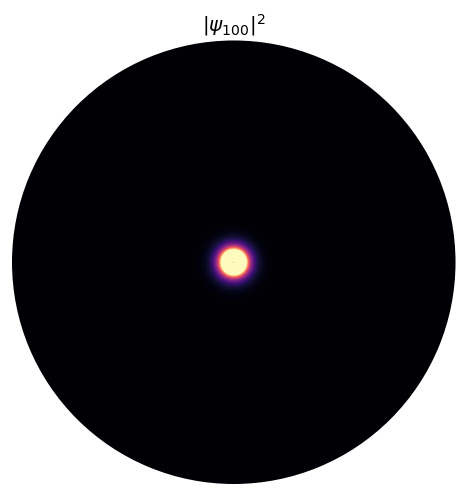

In [18]:
# 1s orbital
Plot_Orbital(norm_radial_0[:,0],1,0,0,20)
plt.title(r'$|\psi_{100}|^2$')
#plt.savefig('1s.png',bbox_inches='tight')

Text(0.5, 1.0, '$|\\psi_{200}|^2$')

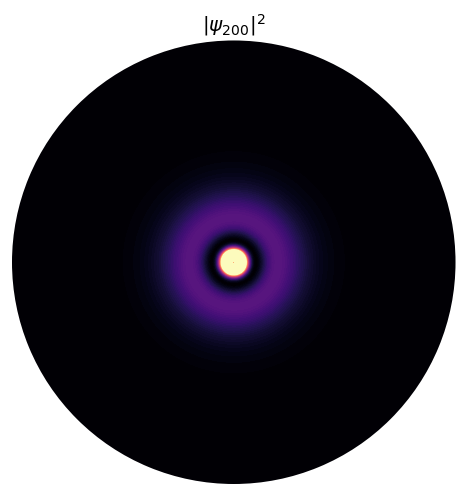

In [19]:
# 2s orbital
Plot_Orbital(norm_radial_0[:,1],2,0,0,20)
plt.title(r'$|\psi_{200}|^2$')
#plt.savefig('2s.png',bbox_inches='tight')

Text(0.5, 1.0, '$|\\psi_{300}|^2$')

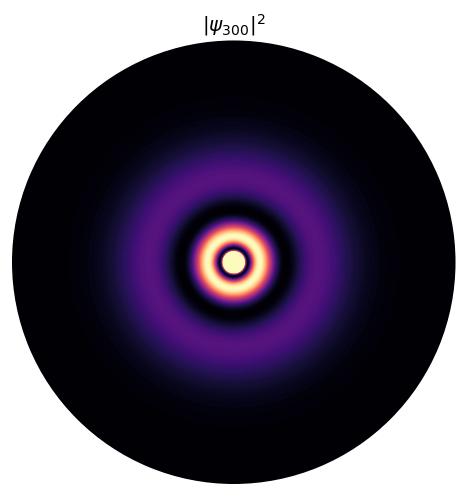

In [20]:
# 3s orbital
Plot_Orbital(norm_radial_0[:,2],3,0,0,30)
plt.title(r'$|\psi_{300}|^2$')
#plt.savefig('3s.png',bbox_inches='tight')

Text(0.5, 1.0, '$|\\psi_{211}|^2$')

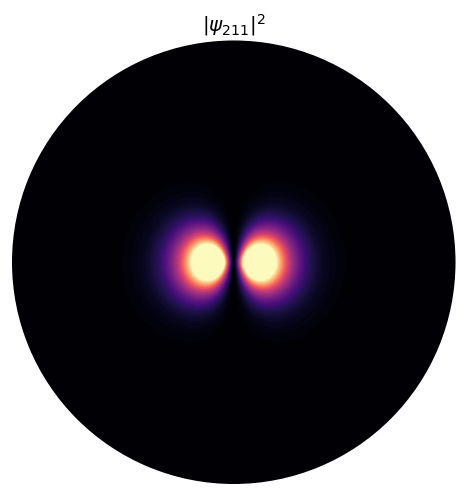

In [21]:
# 2p orbial
Plot_Orbital(norm_radial_1[:,0],2,1,1,20)
plt.title(r'$|\psi_{211}|^2$')
#plt.savefig('2p.png',bbox_inches='tight')

Text(0.5, 1.0, '$|\\psi_{311}|^2$')

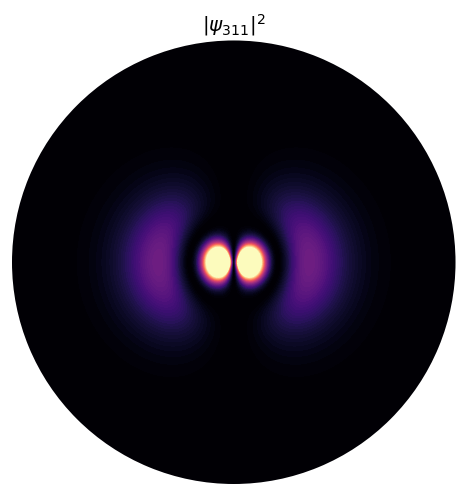

In [22]:
# 3p orbital
Plot_Orbital(norm_radial_1[:,1],3,1,1,30)
plt.title(r'$|\psi_{311}|^2$')
#plt.savefig('3p.png',bbox_inches='tight')

Text(0.5, 1.0, '$|\\psi_{411}|^2$')

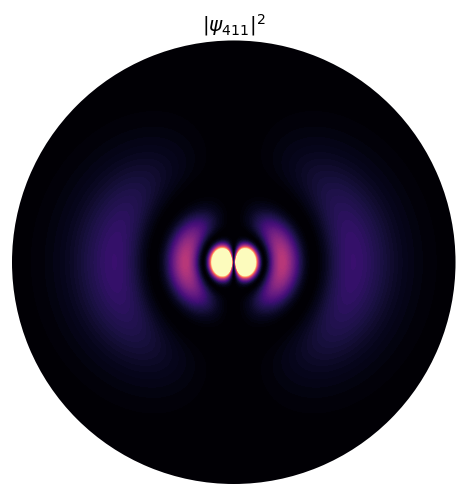

In [23]:
# 4p orbital
Plot_Orbital(norm_radial_1[:,2],4,1,1,40)
plt.title(r'$|\psi_{411}|^2$')
#plt.savefig('4p.png',bbox_inches='tight')

Text(0.5, 1.0, '$|\\psi_{322}|^2$')

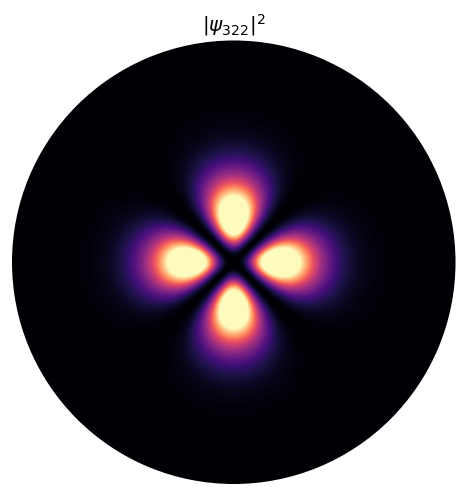

In [24]:
# 3d orbital
Plot_Orbital(norm_radial_2[:,0],3,2,2,30)
plt.title(r'$|\psi_{322}|^2$')
#plt.savefig('3d.png',bbox_inches='tight')

Text(0.5, 1.0, '$|\\psi_{422}|^2$')

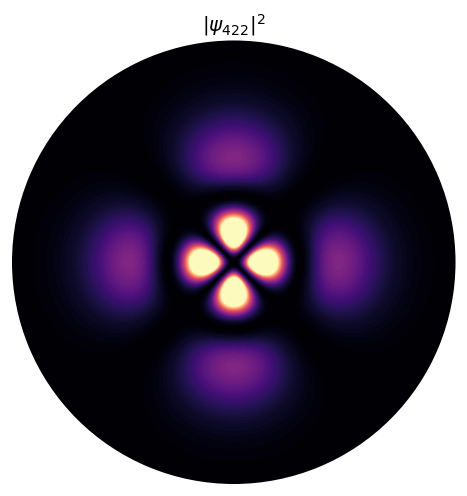

In [25]:
# 4d orbital
Plot_Orbital(norm_radial_2[:,1],2,2,2,40)
plt.title(r'$|\psi_{422}|^2$')
#plt.savefig('4d.png',bbox_inches='tight')

Text(0.5, 1.0, '$|\\psi_{522}|^2$')

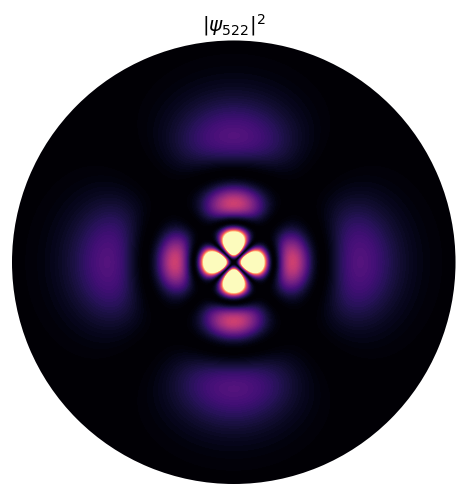

In [26]:
# 5d orbital
Plot_Orbital(norm_radial_2[:,2],3,2,2,60)
plt.title(r'$|\psi_{522}|^2$')
#plt.savefig('5d.png',bbox_inches='tight')

As can be seen, this method is quite accurate for solving the radial equation of the Hydrogen atom. Futhermore, this method could be used to solve more complex problems. There are corrections that can be made to this model such as adding width to the nucleus. This method could be used to solve the Helium atom, which is not analytically solvable due to the interactions between the electrons. This method could also potentially be used to solve bonding orbitals.

# References

D. J. Griffiths, Introduction to Quantum Mechanics (Prentice Hall, New Jersey, 1995).

P. Gono, Hydrogen Atom – Physics, Python, and Programming, https://physicspython.wordpress.com/tag/hydrogen-atom/.